In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [43]:
solar = pd.read_csv("solar_wind.csv")
labels = pd.read_csv("labels.csv")

In [44]:
solar.head()


,period,timedelta,bx_gse,by_gse,bz_gse,theta_gse,phi_gse,bx_gsm,by_gsm,bz_gsm,theta_gsm,phi_gsm,bt,density,speed,temperature,source
0,train_a,0 days 00:00:00,-5.55,3.00,1.25,11.09,153.37,-5.55,3.00,1.25,11.09,153.37,6.80,1.53,383.92,110237.0,ac
1,train_a,0 days 00:01:00,-5.58,3.16,1.17,10.10,151.91,-5.58,3.16,1.17,10.10,151.91,6.83,1.69,381.79,123825.0,ac
2,train_a,0 days 00:02:00,-5.15,3.66,0.85,7.87,146.04,-5.15,3.66,0.85,7.87,146.04,6.77,1.97,389.11,82548.0,ac
3,train_a,0 days 00:03:00,-5.20,3.68,0.68,6.17,146.17,-5.20,3.68,0.68,6.17,146.17,6.74,1.97,389.11,82548.0,ac
4,train_a,0 days 00:04:00,-5.12,3.68,0.49,4.62,145.72,-5.12,3.68,0.49,4.62,145.72,6.65,1.77,384.26,94269.0,ac


In [45]:
labels.head()

,period,timedelta,dst
0,train_a,0 days 00:00:00,-7
1,train_a,0 days 01:00:00,-10
2,train_a,0 days 02:00:00,-10
3,train_a,0 days 03:00:00,-6
4,train_a,0 days 04:00:00,-2


In [46]:
solar.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8392320 entries, 0 to 8392319
Data columns (total 17 columns):
 #   Column       Dtype  
---  ------       -----  
 0   period       object 
 1   timedelta    object 
 2   bx_gse       float64
 3   by_gse       float64
 4   bz_gse       float64
 5   theta_gse    float64
 6   phi_gse      float64
 7   bx_gsm       float64
 8   by_gsm       float64
 9   bz_gsm       float64
 10  theta_gsm    float64
 11  phi_gsm      float64
 12  bt           float64
 13  density      float64
 14  speed        float64
 15  temperature  float64
 16  source       object 
dtypes: float64(14), object(3)
memory usage: 1.1+ GB


In [47]:
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139872 entries, 0 to 139871
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   period     139872 non-null  object
 1   timedelta  139872 non-null  object
 2   dst        139872 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 3.2+ MB


In [48]:
solar.isnull().sum()


period              0
timedelta           0
bx_gse         325888
by_gse         325888
bz_gse         325888
theta_gse      325888
phi_gse        326388
bx_gsm         325888
by_gsm         325888
bz_gsm         325888
theta_gsm      325888
phi_gsm        326388
bt             325888
density        684890
speed          689555
temperature    811768
source         316816
dtype: int64

In [49]:
solar.describe()


,bx_gse,by_gse,bz_gse,theta_gse,phi_gse,bx_gsm,by_gsm,bz_gsm,theta_gsm,phi_gsm,bt,density,speed,temperature
count,8.066432e+06,8.066432e+06,8.066432e+06,8.066432e+06,8.065932e+06,8.066432e+06,8.066432e+06,8.066432e+06,8.066432e+06,8.065932e+06,8.066432e+06,7.707430e+06,7.702765e+06,7.580552e+06
mean,-6.610167e-01,1.097871e-01,-2.274231e-02,1.545628e-01,1.941759e+02,-6.608663e-01,8.842110e-02,-2.912843e-02,1.967691e-01,1.943712e+02,5.606227e+00,4.421726e+00,4.305854e+02,1.150968e+05
std,3.669730e+00,3.975340e+00,3.351972e+00,3.212916e+01,9.662813e+01,3.667605e+00,3.909885e+00,3.430580e+00,3.327889e+01,9.682818e+01,3.110002e+00,4.331911e+00,1.005777e+02,1.203120e+05
min,-5.463000e+01,-5.169000e+01,-5.500000e+01,-8.989000e+01,0.000000e+00,-5.463000e+01,-5.268000e+01,-5.569000e+01,-8.991000e+01,0.000000e+00,3.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00
25%,-3.270000e+00,-2.460000e+00,-1.700000e+00,-2.145000e+01,1.240700e+02,-3.270000e+00,-2.380000e+00,-1.800000e+00,-2.279000e+01,1.246900e+02,3.640000e+00,1.790000e+00,3.568000e+02,3.978700e+04
50%,-6.700000e-01,1.100000e-01,1.000000e-02,1.400000e-01,1.768600e+02,-6.700000e-01,8.000000e-02,0.000000e+00,6.000000e-02,1.776600e+02,4.950000e+00,3.340000e+00,4.097000e+02,7.737100e+04
75%,2.020000e+00,2.640000e+00,1.690000e+00,2.168000e+01,2.864200e+02,2.020000e+00,2.540000e+00,1.790000e+00,2.313000e+01,2.865600e+02,6.720000e+00,5.710000e+00,4.856600e+02,1.512200e+05
max,5.555000e+01,5.760000e+01,7.403000e+01,8.994000e+01,3.600000e+02,5.554000e+01,5.388000e+01,7.245000e+01,8.996000e+01,3.600000e+02,8.053000e+01,1.997000e+02,1.198490e+03,6.223700e+06


In [50]:
solar.columns
labels.columns

Index(['period', 'timedelta', 'dst'], dtype='object')

In [51]:
solar.isnull().sum().sort_values(ascending=False)

temperature    811768
speed          689555
density        684890
phi_gse        326388
phi_gsm        326388
by_gsm         325888
bx_gse         325888
by_gse         325888
bz_gse         325888
theta_gse      325888
bx_gsm         325888
bz_gsm         325888
theta_gsm      325888
bt             325888
source         316816
timedelta           0
period              0
dtype: int64

In [52]:
solar = solar.dropna()
labels = labels.dropna()


In [53]:
df = pd.merge(solar, labels, on=["period", "timedelta"])

In [54]:
solar["timedelta"] = solar["timedelta"].astype(str)
labels["timedelta"] = labels["timedelta"].astype(str)

In [55]:
df = pd.merge(solar, labels, on=["period", "timedelta"], how="inner")

In [56]:
df = df.dropna()

In [57]:
df["target"] = df["dst"].apply(lambda x: 1 if x < -50 else 0)

In [58]:
X = df.drop(["target", "dst"], axis=1)
y = df["target"]

In [59]:
df.shape

(125583, 19)

In [60]:
X = df.drop(["target", "dst", "period", "timedelta", "source"], axis=1)
y = df["target"]


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [62]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [63]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [64]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9705378827089223
Confusion Matrix:
 [[24252    69]
 [  671   125]]


In [65]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
y_pred_rf = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.9745988772544492
Confusion Matrix:
 [[24279    42]
 [  596   200]]


In [67]:
y_prob = rf.predict_proba(X_test)[:,1]
y_pred_new = (y_prob > 0.3).astype(int)
print(confusion_matrix(y_test, y_pred_new))


[[24111   210]
 [  472   324]]


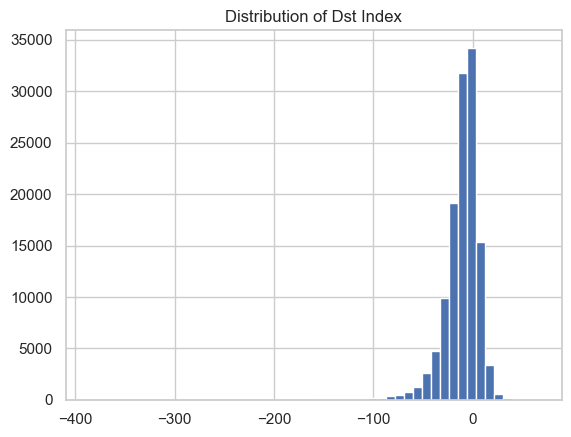

In [68]:
plt.hist(df["dst"], bins=50)
plt.title("Distribution of Dst Index")
plt.show()

In [69]:
print("Solar Wind Data Shape:", solar.shape)
print("\nLabels Data Shape:", labels.shape)
print("\nColumn Names:")
for col in solar.columns:
    print(" -", col)

Solar Wind Data Shape: (7571081, 17)

Labels Data Shape: (139872, 3)

Column Names:
 - period
 - timedelta
 - bx_gse
 - by_gse
 - bz_gse
 - theta_gse
 - phi_gse
 - bx_gsm
 - by_gsm
 - bz_gsm
 - theta_gsm
 - phi_gsm
 - bt
 - density
 - speed
 - temperature
 - source


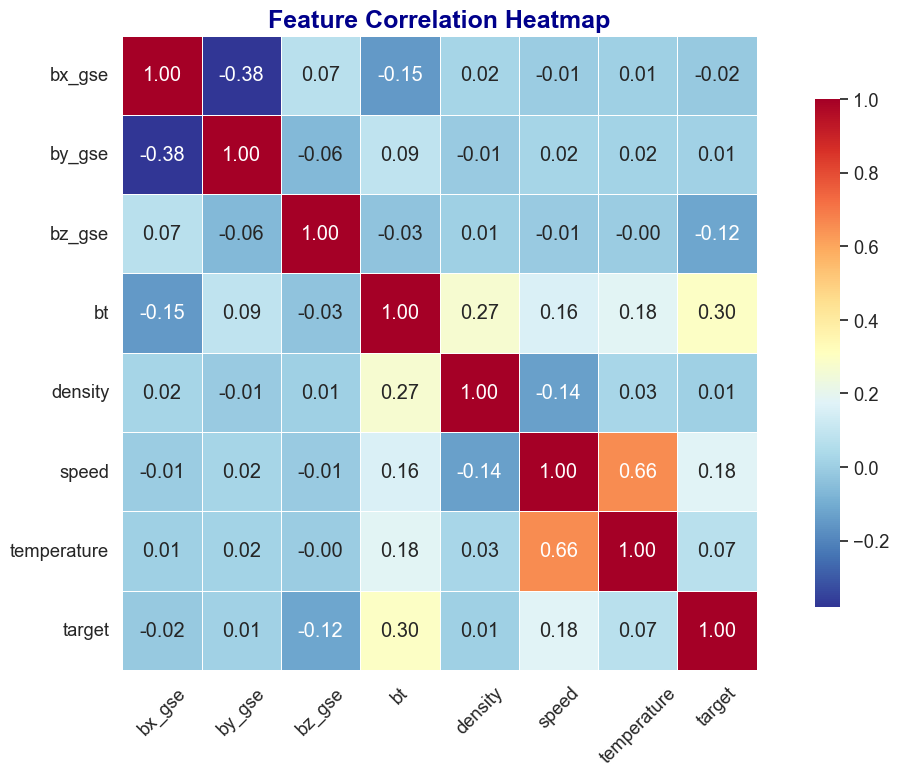

In [70]:

sns.set_theme(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[['bx_gse', 'by_gse', 'bz_gse', 'bt', 'density', 'speed', 'temperature', 'target']].corr(),
    annot=True,
    cmap='RdYlBu_r',
    fmt='.2f',
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Heatmap", fontsize=18, weight='bold', color='darkblue')

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [71]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.9726081936537007

Confusion Matrix:
 [[24238    83]
 [  605   191]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     24321
           1       0.70      0.24      0.36       796

    accuracy                           0.97     25117
   macro avg       0.84      0.62      0.67     25117
weighted avg       0.97      0.97      0.97     25117



In [72]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9556873830473385


In [73]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.931122347414102


Table 1: Final Comparison of Models based on All Metrics


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.974599,0.826446,0.251256,0.385356
1,KNN,0.972608,0.697080,0.239950,0.357009
3,Decision Tree,0.955687,0.320904,0.356784,0.337894
4,Naive Bayes,0.931122,0.212438,0.433417,0.285124
2,Logistic Regression,0.970538,0.644330,0.157035,0.252525


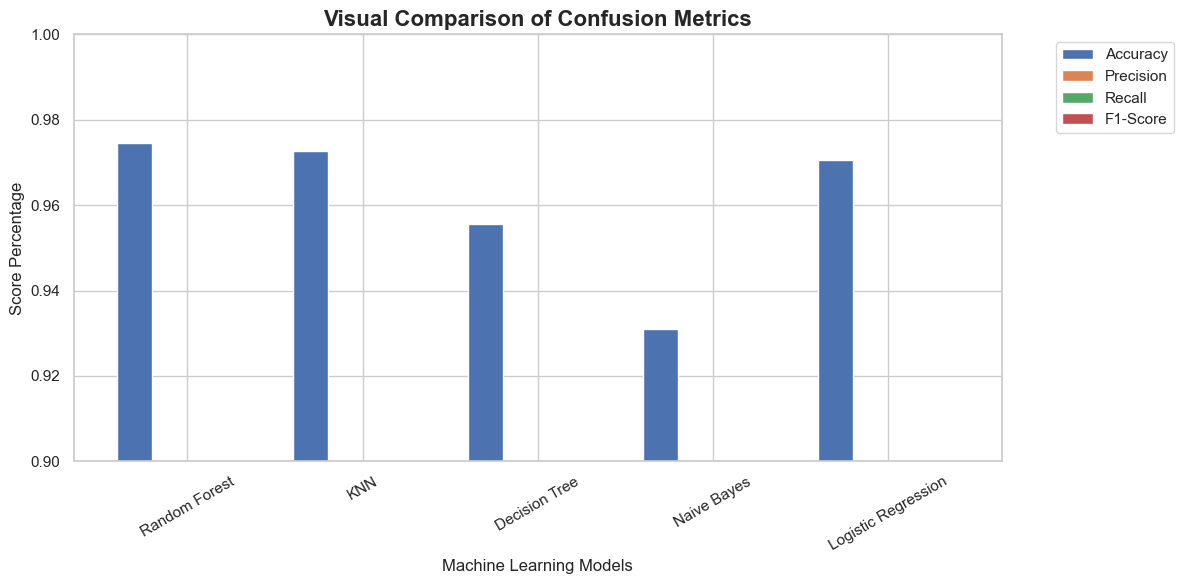

In [74]:
 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_predictions = {
    "Random Forest":y_pred_rf,
    "KNN":y_pred_knn,
    "Logistic Regression": y_pred,
    "Decision Tree": y_pred_dt,
    "Naive Bayes": y_pred_nb
}

 
results_list = []
for name, y_pred in model_predictions.items():
    results_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

 
comparison_df = pd.DataFrame(results_list).sort_values(by='F1-Score', ascending=False)
print("Table 1: Final Comparison of Models based on All Metrics")
display(comparison_df)

 
sns.set_theme(style="whitegrid")
comparison_df.set_index('Model').plot(kind='bar', figsize=(12, 6), width=0.8)

plt.title("Visual Comparison of Confusion Metrics", fontsize=16, weight='bold')
plt.ylabel("Score Percentage")
plt.xlabel("Machine Learning Models")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.ylim(0.9, 1.0)  
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

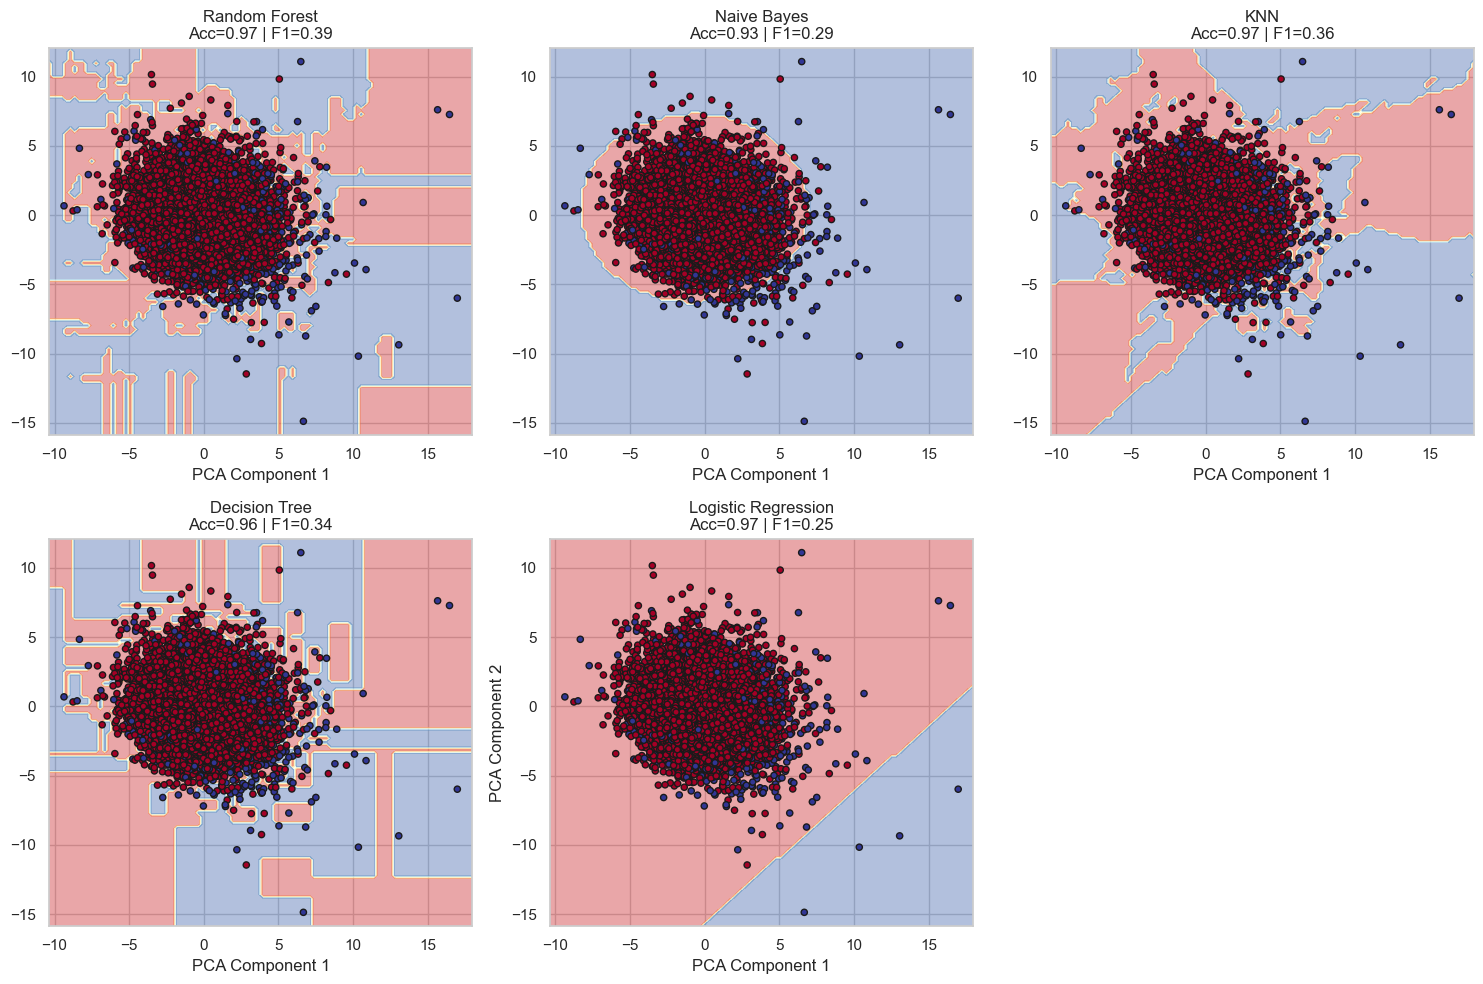

In [87]:
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
 
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

models = [
    ("Random Forest", rf),
    ("Naive Bayes", nb),
    ("KNN", knn),
    ("Decision Tree", dt),
    ("Logistic Regression", model)
]

fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.ravel()

for i, (name, mdl) in enumerate(models):
    ax = axes[i]
 
    mdl.fit(X_train, y_train)

   
    y_pred = mdl.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

   
    mdl_plot = mdl.__class__()
    mdl_plot.fit(X_train_pca, y_train)

   
    DecisionBoundaryDisplay.from_estimator(
        mdl_plot,
        X_test_pca,
        response_method="predict",
        cmap='RdYlBu',
        alpha=0.4,
        ax=ax
    )

  
    ax.scatter(
        X_test_pca[:, 0],
        X_test_pca[:, 1],
        c=y_test,
        cmap='RdYlBu',
        edgecolor='k',
        s=20
    )

    ax.set_title(f"{name}\nAcc={acc:.2f} | F1={f1:.2f}")
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")\


 
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

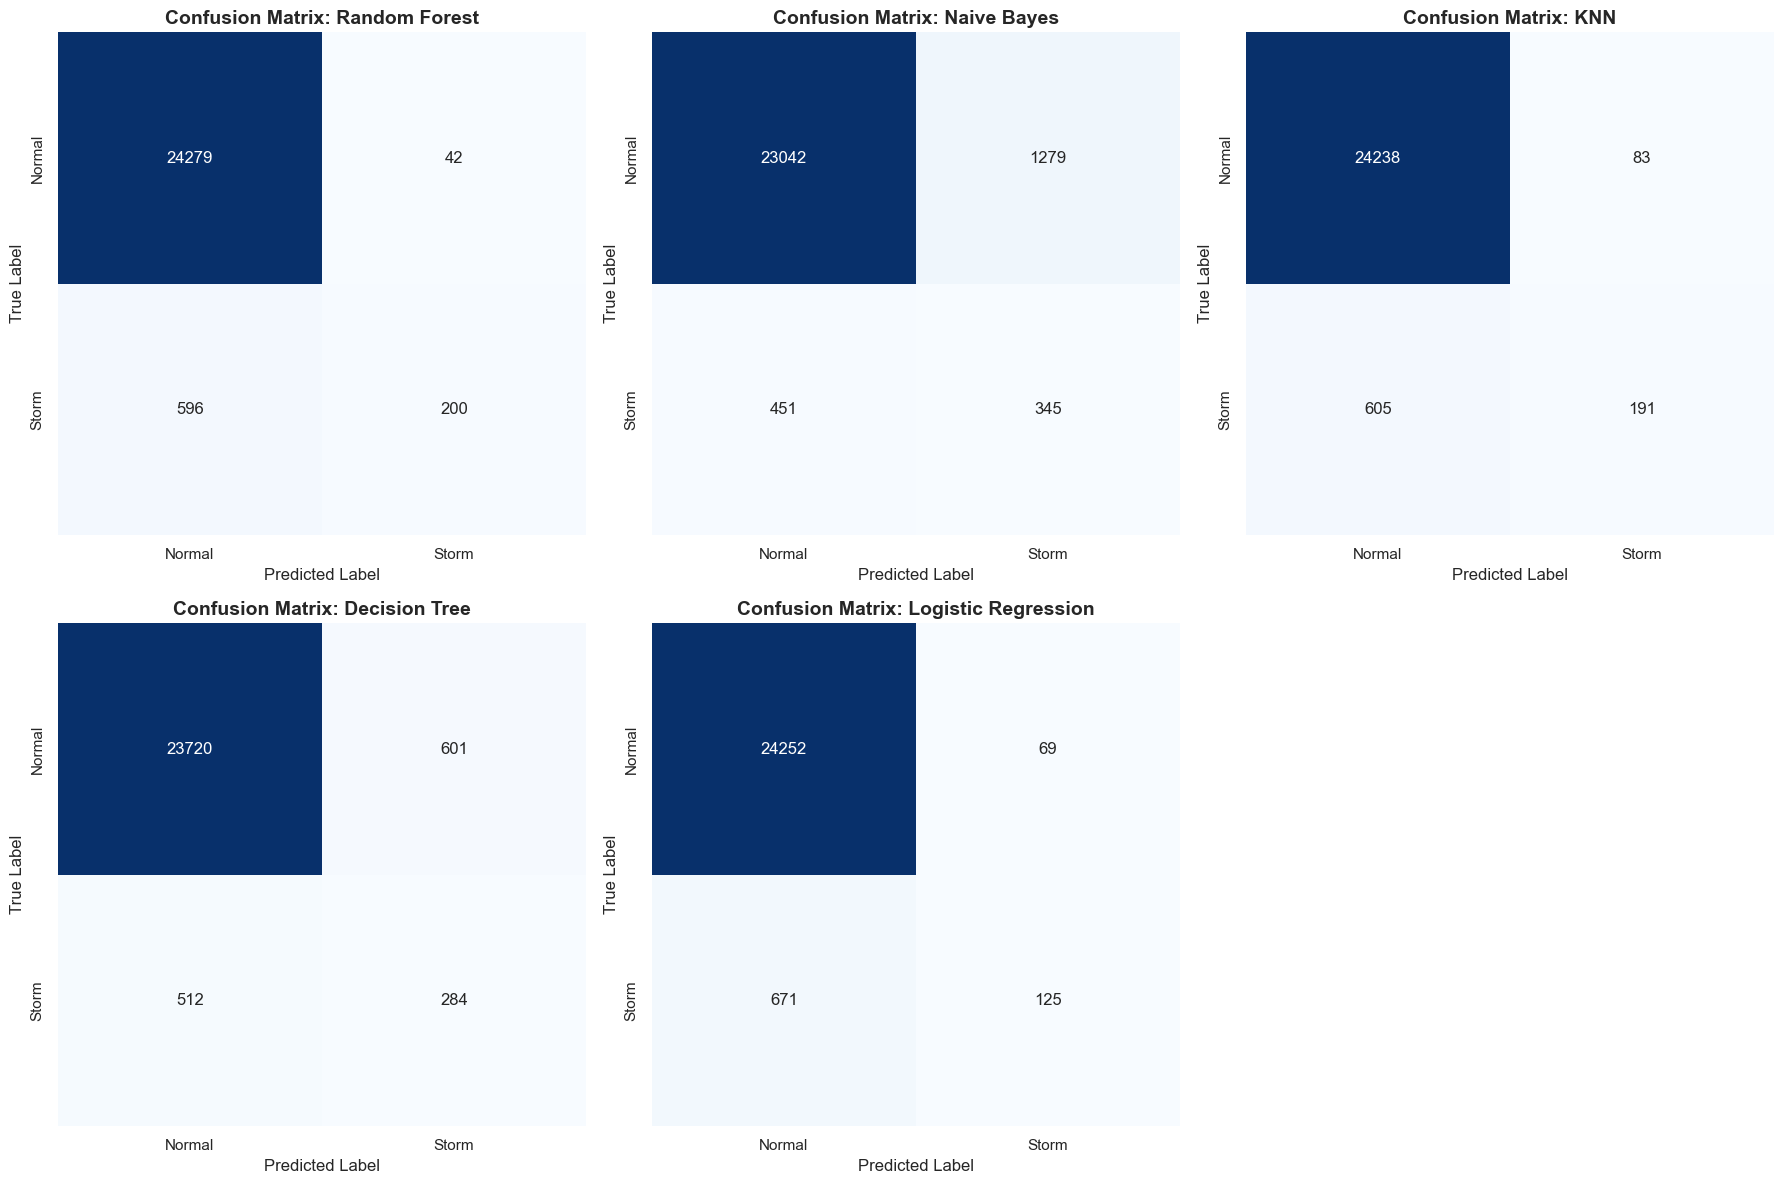

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

 
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

 
models = [
    ("Random Forest", rf),
    ("Naive Bayes", nb),
    ("KNN", knn),
    ("Decision Tree", dt),
    ("Logistic Regression", model)
]

 
for i, (name, mdl) in enumerate(models):
   
    y_pred = mdl.predict(X_test)
    
   
    cm = confusion_matrix(y_test, y_pred)
    
    
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
    
   
    axes[i].set_title(f'Confusion Matrix: {name}', fontsize=14, weight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=12)
    axes[i].set_ylabel('True Label', fontsize=12)
    axes[i].set_xticklabels(['Normal', 'Storm'])
    axes[i].set_yticklabels(['Normal', 'Storm'])

 
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [89]:
from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd

 
threshold = 0.3

optimized_stats = []

 
for name, mdl in models:
 
    y_probs = mdl.predict_proba(X_test)[:, 1]
    
  
    y_pred_adj = (y_probs > threshold).astype(int)
    
   
    acc = accuracy_score(y_test, y_pred_adj)
    rec = recall_score(y_test, y_pred_adj)
    f1 = f1_score(y_test, y_pred_adj)
    
    optimized_stats.append({
        "Model": name,
        "Accuracy": f"{acc:.2f}",
        "Recall (Detection)": f"{rec:.2f}",
        "F1-Score": f"{f1:.2f}"
    })

 
df_final_results = pd.DataFrame(optimized_stats)
print("Results after Threshold Optimization (0.3):")
display(df_final_results)

Results after Threshold Optimization (0.3):


,Model,Accuracy,Recall (Detection),F1-Score
0,Random Forest,0.97,0.41,0.49
1,Naive Bayes,0.92,0.48,0.28
2,KNN,0.97,0.40,0.43
3,Decision Tree,0.96,0.36,0.34
4,Logistic Regression,0.97,0.24,0.34


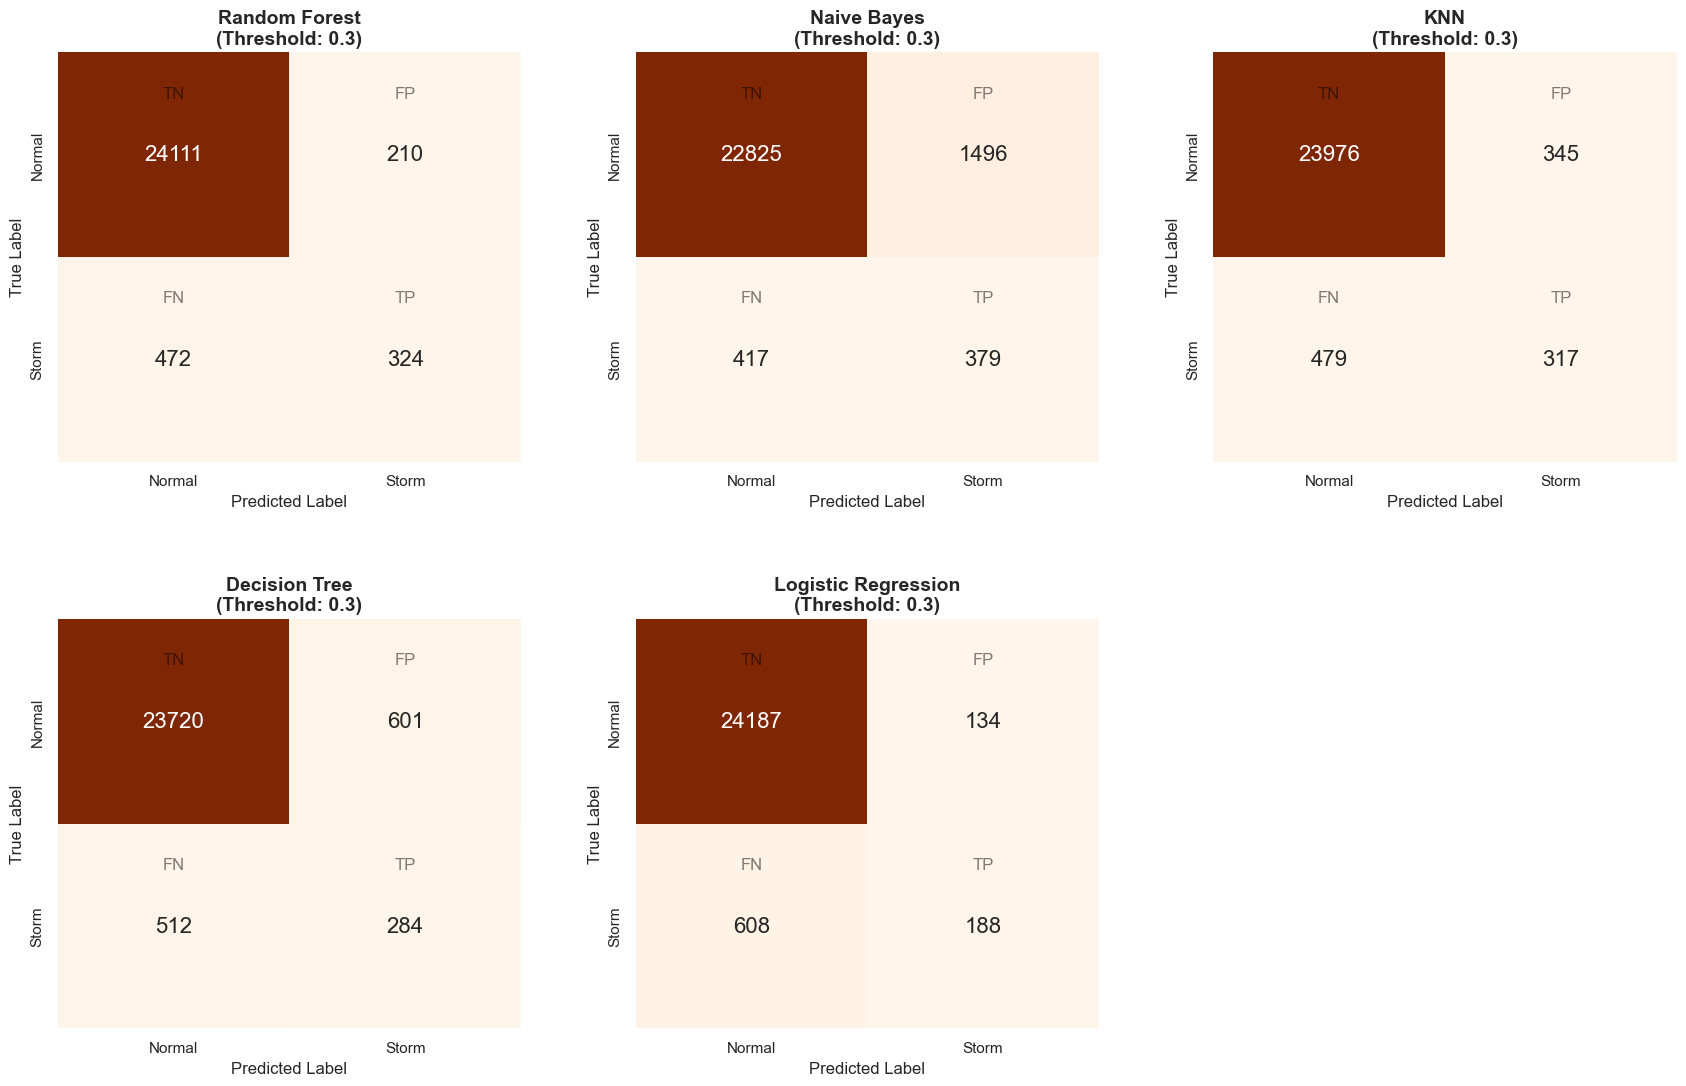

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

 
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

threshold = 0.3

 
for i, (name, mdl) in enumerate(models):
    y_probs = mdl.predict_proba(X_test)[:, 1]
    y_pred_adj = (y_probs > threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_adj)
    
  
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Oranges', cbar=False, 
                annot_kws={"size": 16})  
    
 
    axes[i].text(0.5, 0.2, 'TN', ha='center', va='center', fontsize=12, color='black', alpha=0.5)
    axes[i].text(1.5, 0.2, 'FP', ha='center', va='center', fontsize=12, color='black', alpha=0.5)
    axes[i].text(0.5, 1.2, 'FN', ha='center', va='center', fontsize=12, color='black', alpha=0.5)
    axes[i].text(1.5, 1.2, 'TP', ha='center', va='center', fontsize=12, color='black', alpha=0.5)
    
 
    axes[i].set_title(f'{name}\n(Threshold: {threshold})', fontsize=14, weight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=12)
    axes[i].set_ylabel('True Label', fontsize=12)
    axes[i].set_xticklabels(['Normal', 'Storm'])
    axes[i].set_yticklabels(['Normal', 'Storm'], va='center')

 
fig.delaxes(axes[-1])
plt.tight_layout(pad=4.0)
plt.show()